# Tutorial II: Accessibility and emissions with `cafein`

```{admonition} Credits:

This tutorial was written by Henrikki Tenkanen, the developer of
[`cafein`](https://github.com/cafein-py/cafein),
[`cafein.lca`](https://github.com/cafein-py/cafein.lca),
[`cafein.sampledata`](https://github.com/cafein-py/cafein.sampledata) and
[`transitio`](https://github.com/cafein-py/transitio).
```

## Getting started

There are three options to run the codes in this tutorial:

1. Copy-paste the codes from the website and run them line by line on your own computer with your preferred IDE (JupyterLab, Spyder, PyCharm, etc.).
2. Download this Notebook (see below) and run it in JupyterLab, which you have installed by following the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html).
3. Run the codes in Binder (see below). This needs no installation, but Binder has very limited computational resources, and the analyses in this tutorial need more memory than Binder offers.

### Download the Notebook

You can download this tutorial Notebook to your own computer by clicking the **Download button** from the menu on the top-right section of the website.

- Right-click the option that says `.ipynb` and choose **"Save link as .."**

![Download tutorial Notebook.](../img/Download_notebook_button.png)

### Run the codes on your own computer

Before you can run this Notebook, you need to launch the JupyterLab programming environment, which comes with the course environment (if you have not installed it yet, follow the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html)). To run JupyterLab:

1. Using the terminal or command prompt, change to the folder where you downloaded the Notebook: `$ cd /mydirectory/`
2. Activate the course environment: `$ conda activate sumogis`
3. Launch JupyterLab: `$ jupyter lab`

After these steps, the JupyterLab interface opens in your browser, and you can start executing cells (see the hints below at "Working with Jupyter Notebooks").

#### Alternatively: Run codes in Binder (with limited resources)

You can also run this Notebook by launching a Binder instance from the buttons at the top-right of this page, which look like this:

![Launch Binder](../img/launch_binder.png)

Building the routable networks of this tutorial takes roughly 5 GB of memory, so expect the larger examples to fail in Binder. We recommend running the Notebook on your own computer.

### Working with Jupyter Notebooks

Jupyter Notebooks are documents that combine computer code with rich text elements (such as text, figures, tables and links), and you run them inside the JupyterLab programming environment.

**A couple of hints**:

- You can **execute a cell** by clicking a given cell that you want to run and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd> (or by clicking the "Play" button on top).
- You can **change the cell type** between `Markdown` (for writing text) and `Code` (for writing and executing code) from the dropdown menu above.

See **further details and help for** [**using Notebooks and JupyterLab from here**](https://pythongis.org/part1/chapter-01/nb/04-using-jupyterlab.html).

## Introduction

**cafein** (*Cost of Access For Environment and INdividuals*) is a Python library for routing on multimodal transport networks (walking, cycling, driving and public transport). In addition to travel times, `cafein` reports the distance travelled on each leg of a journey and the **greenhouse-gas emissions** that the journey causes. This makes it possible to study the accessibility of places and the environmental cost of reaching them with the same tool.

`cafein` works with `geopandas` GeoDataFrames: you give the origins and destinations as GeoDataFrames, and you get the results back as tables that you can join to your spatial data. In this tutorial, we will also use three companion libraries:

- `cafein.sampledata` downloads ready-made sample datasets for the Helsinki region.
- `cafein.lca` calculates life-cycle emission factors for different transport modes, which we can use instead of the default factors of `cafein`.
- `transitio` downloads OpenStreetMap and public transport schedule data for any area of interest.

## Data requirements

### Data for creating a routable network

When calculating travel times with `cafein`, you typically need a couple of datasets:

- **A street network dataset from OpenStreetMap** (OSM) in Protocolbuffer Binary (`.pbf`) format:
  - This data is used for finding the fastest routes and calculating the travel times by walking, cycling and driving. In addition, `cafein` uses it for the walking legs to and from the stops, and between stops, when routing with public transport.
- **A transit schedule dataset** in General Transit Feed Specification (GTFS) format:
  - This data contains the information needed for routing with public transport, such as the stops, routes, trips and the times when the vehicles pass a specific stop. You can read about the [GTFS standard from here](https://gtfs.org/documentation/schedule/reference/).
  - `cafein` can also combine several GTFS feeds into one network, e.g. when the bus and the rail connections of a region are published separately.

### Data for origin and destination locations

In addition to the OSM and GTFS datasets, you need data that represents the origin and destination locations of the trips. This data is typically stored in a spatial data format, such as GeoPackage or GeoJSON. As `cafein` reads the locations from GeoDataFrames, you can use any data that you can read with `geopandas`.

### Where to get these datasets?

- **OpenStreetMap data in PBF format**:
  - [transitio](https://transitio.readthedocs.io) and [pyrosm](https://pyrosm.readthedocs.io/en/latest/basics.html#protobuf-file-what-is-it-and-how-to-get-one) libraries download and crop the data for your area of interest directly from Python (based on GeoFabrik, BBBike and other providers).
  - [GeoFabrik](http://download.geofabrik.de/) and [BBBike](https://download.bbbike.org/osm/bbbike/) websites have ready-made extracts for countries, regions and cities.
- **GTFS data**:
  - The [transitio](https://transitio.readthedocs.io) library finds the GTFS feeds that serve a given place, downloads them and crops them to your area of interest. We will use it at the end of this tutorial.
  - The [Mobility Database](https://mobilitydatabase.org/) and [Transitland](https://www.transit.land/operators) websites list GTFS feeds from around the world.

### Sample datasets

In the following tutorial, we use open datasets for the Helsinki region from `cafein.sampledata`:

- The street network is an extract of OpenStreetMap (© OpenStreetMap contributors, [ODbL license](https://www.openstreetmap.org/copyright)).
- The GTFS dataset is the public transport schedule of Helsinki Region Transport (HSL), licensed under [Creative Commons BY 4.0](https://www.hsl.fi/hsl/avoin-data#aineistojen-kayttoehdot).
- The population grid is from [Helsinki Region Environmental Services](https://www.hsy.fi/en/environmental-information/open-data/avoin-data---sivut/population-grid-of-helsinki-metropolitan-area/) (HSY), licensed under Creative Commons BY 4.0.
- The elevation model is from the National Land Survey of Finland, licensed under Creative Commons BY 4.0.
- The libraries are extracted from the same OpenStreetMap data (ODbL).

## Getting started with `cafein`

In this tutorial, we will learn how to calculate travel times and emissions with `cafein` in the Helsinki region, Finland.

### Load and prepare the origin and destination data

Let's start by reading a population grid into a geopandas `GeoDataFrame` that we can use as our destination locations. The helper `cafein.sampledata.helsinki` downloads the sample datasets for Helsinki the first time you use them and stores them on your computer, so the following runs are fast. Each dataset is a path to a file:

In [1]:
import geopandas as gpd
import cafein
import cafein.sampledata.helsinki as helsinki

pop_grid = gpd.read_file(helsinki.population_grid)
pop_grid[["id", "asukkaita", "geometry"]].head()

,id,asukkaita,geometry
0,Vaestotietoruudukko_2025.1,6,"POLYGON ((362054.365 6689582.191, 362061.946 6..."
1,Vaestotietoruudukko_2025.2,6,"POLYGON ((361940.674 6685834.568, 361948.252 6..."
2,Vaestotietoruudukko_2025.3,6,"POLYGON ((361887.631 6684085.685, 361895.208 6..."
3,Vaestotietoruudukko_2025.4,6,"POLYGON ((361880.054 6683835.845, 361887.631 6..."
4,Vaestotietoruudukko_2025.5,8,"POLYGON ((361849.748 6682836.473, 361857.325 6..."


As we can see, the population grid covers the Helsinki region with 250 x 250 meter cells. The `id` column contains a unique identifier for each cell, and the `asukkaita` column contains the number of residents living in each cell (the column names are in Finnish). `cafein` needs a unique `id` column for the origins and destinations, so this dataset is ready to use as such.

Let's see how many cells there are and how the residents are distributed in the region:

Number of grid cells: 5825
Number of residents: 1253793


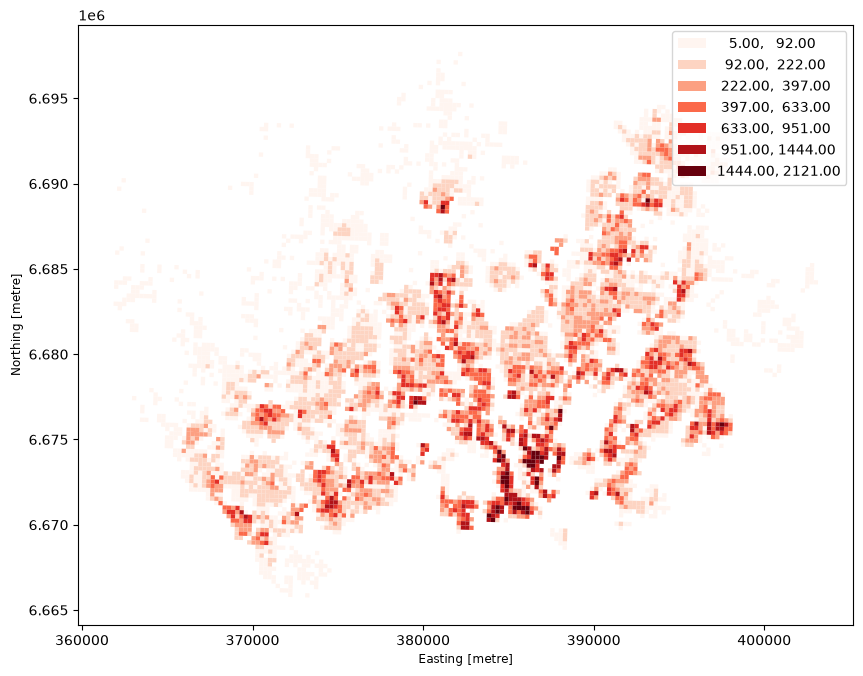

In [2]:
print(f"Number of grid cells: {len(pop_grid)}")
print(f"Number of residents: {pop_grid['asukkaita'].sum()}")
pop_grid.plot(column="asukkaita", cmap="Reds", scheme="natural_breaks", k=7, legend=True, figsize=(10, 8));

#### Convert polygon layer to points

Next, we convert the polygons into points by calculating the centroid of each cell. `cafein` could also route from the polygons directly (it then uses their centroids), but having the points as their own layer makes it explicit which locations we route between. We also reproject the points into WGS84 coordinates (EPSG:4326), which `cafein` uses for its inputs and outputs:

In [3]:
points = pop_grid.copy()
points["geometry"] = points.centroid
points = points.to_crs(epsg=4326)
points[["id", "asukkaita", "geometry"]].head(3)

,id,asukkaita,geometry
0,Vaestotietoruudukko_2025.1,6,POINT (24.50461 60.32041)
1,Vaestotietoruudukko_2025.2,6,POINT (24.50512 60.28675)
2,Vaestotietoruudukko_2025.3,6,POINT (24.50535 60.27105)


#### Retrieve the origin location by geocoding an address

Let's geocode the address of the Helsinki Railway Station with `osmnx` and use it as our **origin** location:

In [4]:
import osmnx as ox
from shapely.geometry import Point

lat, lon = ox.geocode("Rautatieasema, Helsinki")
origin = gpd.GeoDataFrame({"id": ["station"], "name": ["Helsinki Railway Station"]}, geometry=[Point(lon, lat)], crs="EPSG:4326")
origin.explore(color="red", marker_kwds={"radius": 12}, max_zoom=14)

### Build the transport network

Virtually all operations of `cafein` need a transport network. We build one from the GTFS data and the OpenStreetMap extract with `cafein.TransportNetwork.from_gtfs()`. Under the hood, `cafein` reads the public transport schedules, snaps the stops to the street network, and builds the walking paths that connect stops to each other and to any coordinate we route from. This takes a minute or two:

In [5]:
%%time
network = cafein.TransportNetwork.from_gtfs(helsinki.gtfs, osm_pbf=helsinki.osm_pbf)

.../site-packages/cafein/streets.py:374: UserWarning: 1009 stop(s) are farther than 1600.0 m from the walking network and get no footpaths
  snapped = _snap_to_edges(stop_points, edges, max_snap_distance)


CPU times: user 33.1 s, sys: 1.61 s, total: 34.7 s
Wall time: 31.6 s


Now the routable network is stored in the `network` variable. The warning tells that some stops lie far from any walkable street (e.g. stops on islands that the street extract does not cover); `cafein` leaves those stops without a walking connection.

A GTFS feed is valid only for a limited period of time, so the departure time of our trips needs to fall within the feed's service period. Let's check the period with the `service_window` attribute:

In [6]:
network.service_window

(datetime.date(2026, 8, 20), datetime.date(2026, 10, 18))

We will use Tuesday, 1 September 2026, at 8 AM as our departure time, which is inside the service window:

In [7]:
import datetime

departure = datetime.datetime(2026, 9, 1, 8, 0)

### Compute travel times and emissions from one to all locations

A **travel cost matrix** is a table that shows the travel costs (e.g. travel time and emissions) between given origins and destinations. We calculate one with `cafein.TravelCostMatrix`, which takes the network, the origins, the destinations and the departure time. With a `TransportNetwork`, `cafein` routes by public transport and walking:

In [8]:
travel_costs = cafein.TravelCostMatrix(network, origins=origin, destinations=points, departure=departure)
travel_costs.head()

.../site-packages/cafein/matrices.py:1193: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, factors, components),


,from_id,to_id,travel_time,transfers,transit_distance_m,walk_distance_m,emissions
0,station,Vaestotietoruudukko_2025.1,84,1,40043.0,806.119352,2346.904
1,station,Vaestotietoruudukko_2025.2,89,1,37676.0,1116.717275,2129.140
2,station,Vaestotietoruudukko_2025.3,86,1,34420.0,1277.658010,1829.588
3,station,Vaestotietoruudukko_2025.4,84,1,34420.0,1132.672705,1829.588
4,station,Vaestotietoruudukko_2025.5,103,1,33030.0,2460.262238,1701.708


As a result, we get a `pandas.DataFrame` with one row per origin-destination pair:

| Column | Description |
| ------ | ----------- |
| `from_id`, `to_id` | The ids of the origin and the destination |
| `travel_time` | The door-to-door travel time in minutes (including walking and waiting) |
| `transfers` | The number of transfers between public transport vehicles |
| `transit_distance_m` | The distance travelled in public transport vehicles in meters |
| `walk_distance_m` | The distance walked in meters |
| `emissions` | The greenhouse-gas emissions of the trip in grams of CO₂ equivalent (g CO₂e) |

`cafein` calculates the emissions of each public transport leg by multiplying the distance travelled with an **emission factor** of the vehicle type (in g CO₂e per passenger-kilometer). By default, `cafein` uses life-cycle factors calibrated to the Finnish electricity mix, which suit our Helsinki data. Walking causes no emissions.

Let's take a look at the descriptive statistics of the results:

In [9]:
travel_costs.describe().round(1)

,travel_time,transfers,transit_distance_m,walk_distance_m,emissions
count,5825.0,5825.0,5825.0,5825.0,5812.0
mean,46.0,0.9,16289.6,893.2,741.8
std,18.4,0.5,7210.6,450.6,514.8
min,4.0,0.0,0.0,223.7,0.0
25%,34.0,1.0,11383.0,615.9,390.1
50%,43.0,1.0,15921.0,804.0,615.2
75%,54.0,1.0,21400.0,1043.2,955.0
max,143.0,3.0,42275.0,4696.2,2820.3


Notice that the `emissions` column has a few values fewer than the other columns. The fastest journeys to a handful of cells use the ferry to Suomenlinna, and `cafein` has no default emission factor for ferries, so it leaves the emissions of those journeys empty (`NaN`) and warns about it. We will come back to emission factors at the end of this tutorial.

Next, let's join the results to the population grid so that we can map them:

In [10]:
grid_costs = pop_grid.merge(travel_costs, left_on="id", right_on="to_id")
grid_costs[["id", "asukkaita", "travel_time", "emissions"]].head()

,id,asukkaita,travel_time,emissions
0,Vaestotietoruudukko_2025.1,6,84,2346.904
1,Vaestotietoruudukko_2025.2,6,89,2129.140
2,Vaestotietoruudukko_2025.3,6,86,1829.588
3,Vaestotietoruudukko_2025.4,6,84,1829.588
4,Vaestotietoruudukko_2025.5,8,103,1701.708


Now we have the travel times and emissions attached to each grid cell, and we can visualize them side by side:

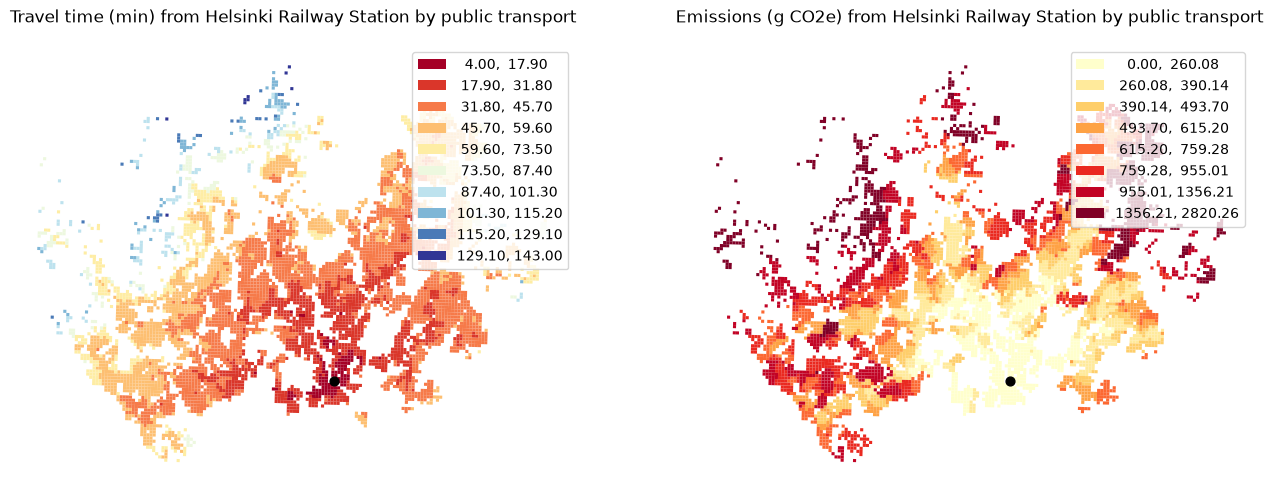

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
grid_costs.plot(ax=ax1, column="travel_time", cmap="RdYlBu", scheme="equal_interval", k=10, legend=True)
grid_costs.plot(ax=ax2, column="emissions", cmap="YlOrRd", scheme="quantiles", k=8, legend=True)
for ax, title in [(ax1, "Travel time (min)"), (ax2, "Emissions (g CO2e)")]:
    origin.to_crs(grid_costs.crs).plot(ax=ax, color="black", markersize=40)
    ax.set_title(f"{title} from Helsinki Railway Station by public transport")
    ax.set_axis_off()

As we can see, the travel times grow with the distance from the railway station, but they also follow the metro and the commuter rail lines, along which you can travel far within a short time. The emissions grow mainly with the distance travelled in vehicles, and they also depend on the vehicle type: buses cause more emissions per passenger-kilometer than electric trains, metro and trams.

### Compute travel times from all to all locations

Let's continue by calculating travel times between all locations. Routing between all 5,825 grid cells would mean almost 34 million origin-destination pairs, so we use a coarser grid for this example. The `cafein.zones` module creates a grid of [H3 hexagons](https://h3geo.org/) that covers a given area. At **resolution** 7, each hexagon covers roughly 5 km²:

In [12]:
from cafein import zones

hexagons = zones.h3_grid(pop_grid, 7)
print(f"Number of hexagons: {len(hexagons)}")
hexagons.head(3)

Number of hexagons: 229


,id,centroid_lat,centroid_lon,geometry
0,870899604ffffff,60.304344,24.545655,"POLYGON ((24.52855 60.29721, 24.54738 60.29247..."
1,870899606ffffff,60.287718,24.566209,"POLYGON ((24.54911 60.28059, 24.56793 60.27584..."
2,870899608ffffff,60.347097,24.648494,"POLYGON ((24.63133 60.33997, 24.65019 60.33522..."


The hexagon grid has an `id` column, and `cafein` routes from the hexagons' centroids (the `centroid_lat` and `centroid_lon` columns). Now we can use the same hexagons as the origins and the destinations:

In [13]:
%%time
all_to_all = cafein.TravelCostMatrix(network, origins=hexagons, destinations=hexagons, departure=departure)
print(f"Number of origin-destination pairs: {len(all_to_all)}")

.../site-packages/cafein/matrices.py:1193: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, factors, components),


Number of origin-destination pairs: 49735
CPU times: user 10.4 s, sys: 71.7 ms, total: 10.5 s
Wall time: 1.33 s


To estimate how well each hexagon is connected to the rest of the region, we calculate the median travel time from each hexagon to all others:

In [14]:
median_times = all_to_all.groupby("from_id")["travel_time"].median().rename("median_travel_time")
overall_access = hexagons.merge(median_times, left_on="id", right_index=True)
print(f"Mean of the median travel times: {overall_access['median_travel_time'].mean():.1f} minutes")
overall_access.explore("median_travel_time", cmap="Blues", scheme="natural_breaks", k=5)

Mean of the median travel times: 95.3 minutes


The hexagons in the city center and along the rail lines have the shortest median travel times to the rest of the region, while the hexagons on the edges of the region have the longest ones (a classic **edge effect**: the region's own boundary limits where people can travel to).

## Detailed itineraries

The travel cost matrix tells how long a trip takes, but not which route it takes. `cafein.DetailedItineraries` returns the full journeys, with one row per **leg** of each journey (walking to a stop, riding a vehicle, transferring, walking to the destination). Let's geocode three destinations in different parts of the region (Tapiola in Espoo, Itäkeskus in eastern Helsinki and Tikkurila in Vantaa) and calculate the journeys to them from the railway station:

In [15]:
places = {"Tapiola": "Tapiola, Espoo", "Itäkeskus": "Itäkeskus, Helsinki", "Tikkurila": "Tikkurila, Vantaa"}
coordinates = [ox.geocode(query) for query in places.values()]
destinations = gpd.GeoDataFrame({"id": list(places)}, geometry=[Point(lon, lat) for lat, lon in coordinates], crs="EPSG:4326")
itineraries = cafein.DetailedItineraries(network, origins=origin, destinations=destinations, departure=departure)
itineraries.drop(columns="geometry").head(10)

,from_id,to_id,option,segment,leg_type,departure_s,arrival_s,travel_time,from_stop,to_stop,trip_id,route_id,route_short_name,distance_m,distance_provenance,emissions
0,station,Tapiola,0,0,access,28800,28978,3,NaN,1020602,NaN,NaN,NaN,177.015238,NaN,0.000
1,station,Tapiola,0,1,transit,28980,29820,14,1020602,2211602,31M2_20260820_Ti_2_0742,31M2,M2,10377.000000,shape_dist,259.425
2,station,Tapiola,0,2,egress,29820,30123,5,2211602,NaN,NaN,NaN,NaN,302.567090,NaN,0.000
3,station,Itäkeskus,0,0,access,28800,28979,3,NaN,1020601,NaN,NaN,NaN,178.149226,NaN,0.000
4,station,Itäkeskus,0,1,transit,28980,29880,15,1020601,1453601,31M2_20260820_Ti_1_0748,31M2,M2,10266.000000,shape_dist,256.650
5,station,Itäkeskus,0,2,transfer,29880,29903,0,1453601,1000111,NaN,NaN,NaN,22.574574,NaN,0.000
6,station,Itäkeskus,0,3,egress,29903,30149,4,1000111,NaN,NaN,NaN,NaN,245.914848,NaN,0.000
7,station,Tikkurila,0,0,access,28800,28924,2,NaN,1020501,NaN,NaN,NaN,123.589368,NaN,0.000
8,station,Tikkurila,0,1,transit,29400,30240,14,1020501,4610504,3001R_20260823_Ti_1_0810,3001R,R,15710.000000,shape_dist,392.750
9,station,Tikkurila,0,2,egress,30240,30665,7,4610504,NaN,NaN,NaN,NaN,424.693445,NaN,0.000


As we can see, the result contains much more information than the travel cost matrix:

| Column | Description |
| ------ | ----------- |
| `option` | The number of the alternative journey between the origin and the destination |
| `segment` | The order of the leg within the journey |
| `leg_type` | The type of the leg: `access` (walking to the first stop), `transit`, `transfer`, `egress` (walking from the last stop) or `walk` (walking all the way) |
| `departure_s`, `arrival_s` | The departure and arrival times in seconds since midnight |
| `travel_time` | The duration of the leg in minutes |
| `from_stop`, `to_stop` | The stops where a transit leg starts and ends |
| `trip_id`, `route_id`, `route_short_name` | The vehicle trip and the line used on a transit leg |
| `distance_m` | The distance of the leg in meters |
| `distance_provenance` | How the distance was measured: e.g. `shape_dist` means along the route geometry of the GTFS feed |
| `emissions` | The emissions of the leg in g CO₂e |
| `geometry` | The geometry of the leg |

The result is a GeoDataFrame, so we can draw the journeys on a map right away. Hover over the lines to see the details of each leg:

In [16]:
itineraries["leg"] = itineraries["leg_type"] + " " + itineraries["route_short_name"].fillna("")
m = itineraries.explore(column="leg", tooltip=["option", "leg", "travel_time", "distance_m", "emissions"], style_kwds={"weight": 5})
origin.explore(m=m, color="black", marker_kwds={"radius": 8})

## Fastest vs. lowest-emission journeys

The fastest journey is not always the one with the lowest emissions. A slightly slower journey by metro or tram can, for example, cause less emissions than a faster bus connection. With `candidates="pareto"`, `DetailedItineraries` returns all journeys for which no other journey is both faster and cleaner (the so-called **Pareto set**). Let's calculate them for the trip to Tapiola:

In [17]:
pareto = cafein.DetailedItineraries(network, origins=origin, destinations=destinations.head(1), departure=departure, candidates="pareto")
journeys = cafein.compare_to_fastest(pareto)
journeys.head(8)

.../site-packages/cafein/itineraries.py:968: UserWarning: no emission factor matches route_type(s) [4]; journeys riding the affected trips carry no emissions
  emissions.trip_factors(network, transit_factors, components)


,from_id,to_id,option,travel_time,emissions,distance_m,fastest,travel_time_delta,emissions_delta,distance_m_delta
0,station,Tapiola,0,22,259.425,10856.582328,True,0.0,0.000,0.000000
1,station,Tapiola,1,29,246.125,10877.031829,False,7.0,-13.300,20.449502
2,station,Tapiola,2,38,223.948,9572.069543,False,16.0,-35.477,-1284.512785
3,station,Tapiola,3,42,190.000,9527.873440,False,20.0,-69.425,-1328.708888
4,station,Tapiola,4,60,166.375,9633.756384,False,38.0,-93.050,-1222.825944
5,station,Tapiola,5,67,148.850,9575.891726,False,45.0,-110.575,-1280.690602
6,station,Tapiola,6,80,120.375,9265.888768,False,58.0,-139.050,-1590.693559
7,station,Tapiola,7,95,95.175,9173.687108,False,73.0,-164.250,-1682.895219


The `compare_to_fastest()` function sums the legs of each journey and compares the journeys with the fastest one: `travel_time_delta` tells how many minutes longer a journey takes, and `emissions_delta` how many grams of CO₂e it saves (negative values) compared to the fastest journey. As we can see, the fastest trip to Tapiola takes 22 minutes by metro and causes about 260 g CO₂e. The cleaner alternatives exist, but they cost extra travel time: the journey that takes 20 minutes longer saves about a quarter of the emissions, and the cleanest journey in the table takes over an hour longer. This way, we can see how much extra travel time a traveler would need to accept to reduce the emissions of their trip.

`TravelCostMatrix` can also report the lowest-emission journey for every origin-destination pair instead of the fastest one, with the parameter `optimize="emissions"`. It then searches the journeys that depart within a given time window (`departure_time_window`, in minutes), optionally limited by a maximum travel time (`max_travel_time`).

## Cycling with elevation

`cafein` can also route by walking, cycling and driving. For these modes, we build a `cafein.StreetNetwork` from the OpenStreetMap data. When we also give it an **elevation model** (a raster of terrain heights), `cafein` adjusts the cycling speeds to the slopes: riding uphill is slower than riding downhill. Let's build a cycling network with the elevation model of the Helsinki region:

In [18]:
%%time
bike_network = cafein.StreetNetwork.from_osm(helsinki.osm_pbf, modes=["bicycle"], dem=helsinki.dem)

CPU times: user 9.85 s, sys: 625 ms, total: 10.5 s
Wall time: 10.2 s


Now we can calculate the cycling travel times in the same way as before. With a `StreetNetwork`, we tell the mode with the `transport_mode` parameter:

In [19]:
bike_costs = cafein.TravelCostMatrix(bike_network, origins=origin, destinations=points, transport_mode="bicycle")
bike_costs.head()

,from_id,to_id,travel_time,distance_m,network_distance_m,connector_distance_m,distance_provenance,emissions
0,station,Vaestotietoruudukko_2025.23,119,27908.587151,27823.907724,84.679427,osm_edge_length+geodesic_connector,1029.484586
1,station,Vaestotietoruudukko_2025.24,118,27943.251765,27892.301097,50.950667,osm_edge_length+geodesic_connector,1032.015141
2,station,Vaestotietoruudukko_2025.25,118,28005.172610,27977.074405,28.098205,osm_edge_length+geodesic_connector,1035.151753
3,station,Vaestotietoruudukko_2025.29,118,27734.586320,27647.490724,87.095596,osm_edge_length+geodesic_connector,1022.957157
4,station,Vaestotietoruudukko_2025.30,119,27926.844709,27835.533724,91.310985,osm_edge_length+geodesic_connector,1029.914748


For street modes, the result reports the distance (`distance_m`) instead of the transit and walking distances. The emissions of cycling are not zero: the default factor of `cafein` includes the manufacturing of the bike and the extra food that cycling requires.

Let's compare cycling with public transport and see where cycling is the faster option:

Cycling is faster to 10% of the grid cells


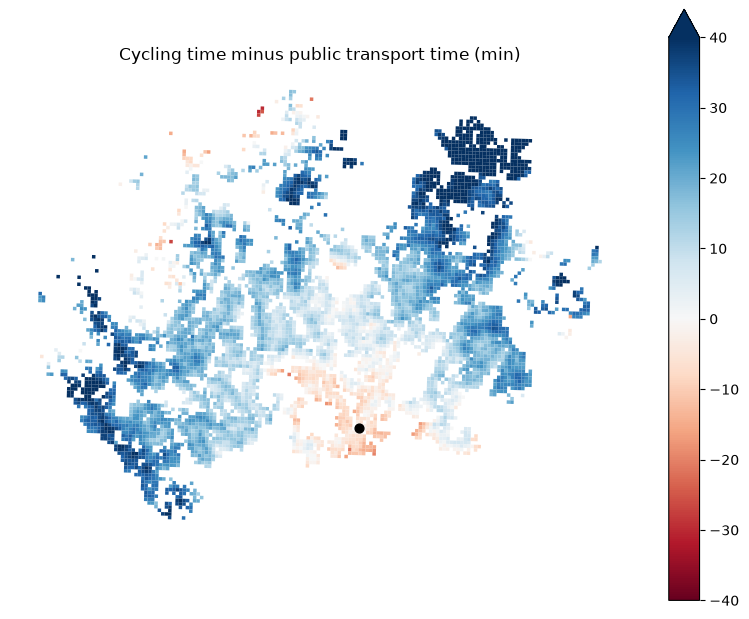

In [20]:
modes = travel_costs[["to_id", "travel_time"]].merge(bike_costs[["to_id", "travel_time"]], on="to_id", suffixes=("_pt", "_bike"))
modes["bike_minus_pt"] = modes["travel_time_bike"] - modes["travel_time_pt"]
grid_modes = pop_grid.merge(modes, left_on="id", right_on="to_id")
print(f"Cycling is faster to {(grid_modes['bike_minus_pt'] < 0).mean():.0%} of the grid cells")
ax = grid_modes.plot(column="bike_minus_pt", cmap="RdBu", vmin=-40, vmax=40, legend=True, figsize=(10, 8))
origin.to_crs(grid_modes.crs).plot(ax=ax, color="black", markersize=40)
ax.set_title("Cycling time minus public transport time (min)")
ax.set_axis_off();

The blue cells are faster to reach by bike and the red ones by public transport. Within a few kilometers from the railway station, cycling is typically as fast as or faster than public transport, while public transport wins the long trips along the metro and rail lines.

## Calculate catchment areas

One typical accessibility analysis is to find out the **catchment area** of each service location, such as a library: the area from which the library is the closest one to reach. Let's read the libraries of the Helsinki region from the sample data:

In [21]:
libraries = gpd.read_file(helsinki.pois.library)
libraries["id"] = libraries["osm_id"].astype(str)
libraries["geometry"] = libraries.to_crs(epsg=3067).centroid.to_crs(epsg=4326)
print(f"Number of libraries: {len(libraries)}")
libraries.explore(color="red", marker_kwds={"radius": 5})

Number of libraries: 102


`cafein.NearestDestinations` finds the closest destinations (here, the closest library) for each origin. Here we use the grid cells as the origins, so that `cafein` routes from each cell's centroid:

In [22]:
%%time
nearest = cafein.NearestDestinations(network, origins=pop_grid.to_crs(epsg=4326), destinations=libraries, departure=departure, k=1)
nearest.head()

CPU times: user 4min 19s, sys: 537 ms, total: 4min 20s
Wall time: 27.4 s


,from_id,rank,destination_id,cost
0,Vaestotietoruudukko_2025.1,1,8911452721,51.0
1,Vaestotietoruudukko_2025.2,1,8911452721,59.0
2,Vaestotietoruudukko_2025.3,1,8911452721,59.0
3,Vaestotietoruudukko_2025.4,1,8911452721,59.0
4,Vaestotietoruudukko_2025.5,1,8911452721,29.0


The result tells for each grid cell (`from_id`) the closest library (`destination_id`) and the travel time to it in minutes (`cost`). The `dominance_areas()` method dissolves the grid cells by their closest library, which gives us the catchment areas:

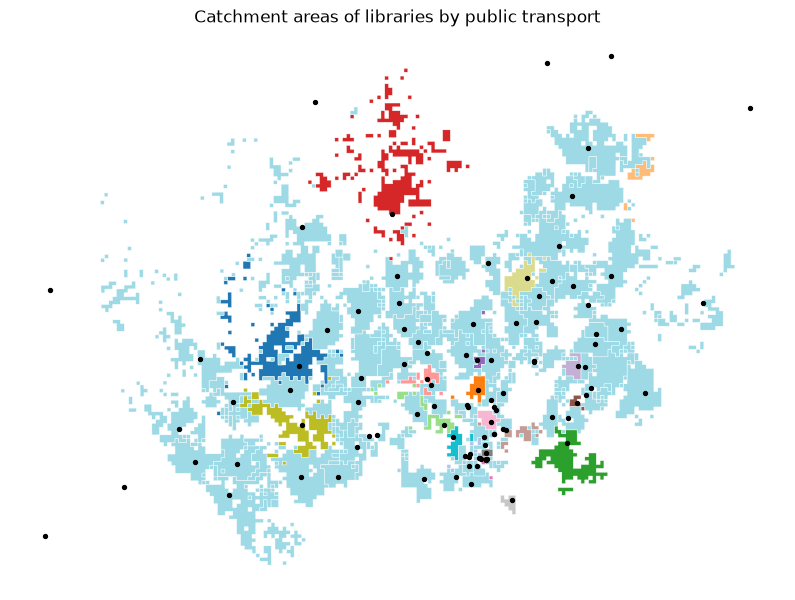

In [23]:
catchments = nearest.dominance_areas(pop_grid.to_crs(epsg=4326))
ax = catchments.plot(column="destination_id", cmap="tab20", edgecolor="white", linewidth=0.3, figsize=(10, 8))
libraries.plot(ax=ax, color="black", markersize=8)
ax.set_title("Catchment areas of libraries by public transport")
ax.set_axis_off();

## Analyze accessibility

After we have calculated the travel times to the closest services, we can start analyzing accessibility. There are various ways to analyze how accessible services are. Let's first calculate how many residents can reach a library within 15 minutes by public transport or walking:

In [24]:
threshold = 15
grid_nearest = pop_grid.merge(nearest, left_on="id", right_on="from_id")
within = grid_nearest.loc[grid_nearest["cost"] <= threshold]
share = within["asukkaita"].sum() / pop_grid["asukkaita"].sum()
print(f"Residents within {threshold} minutes from a library: {within['asukkaita'].sum()} ({share:.0%})")

Residents within 15 minutes from a library: 742440 (59%)


With this information, we can start evaluating whether the level of access in the region is sufficient and equitable. Often the interesting question is "who does not have access?", i.e. who is left out. What counts as a reasonable travel time threshold depends on the service and on the travelers, and it is a question that requires careful consideration in each analysis.

## Cumulative opportunities

Another commonly used approach is to count how many services a person can reach within a given travel time budget. This is called the **cumulative opportunities** measure. `cafein.Accessibility` calculates it for several budgets at once:

In [25]:
%%time
access = cafein.Accessibility(network, origins=points, destinations=libraries, departure=departure, budgets=(15, 30))
access.head()

CPU times: user 4min 24s, sys: 714 ms, total: 4min 25s
Wall time: 28.5 s


,from_id,opportunity,budget,accessibility
0,Vaestotietoruudukko_2025.1,count,15.0,0.0
1,Vaestotietoruudukko_2025.1,count,30.0,0.0
2,Vaestotietoruudukko_2025.2,count,15.0,0.0
3,Vaestotietoruudukko_2025.2,count,30.0,0.0
4,Vaestotietoruudukko_2025.3,count,15.0,0.0


The result is in a long format: one row per origin and budget, where `accessibility` is the number of libraries reachable within the budget (`budget`, in minutes). Let's map the number of libraries reachable within 30 minutes:

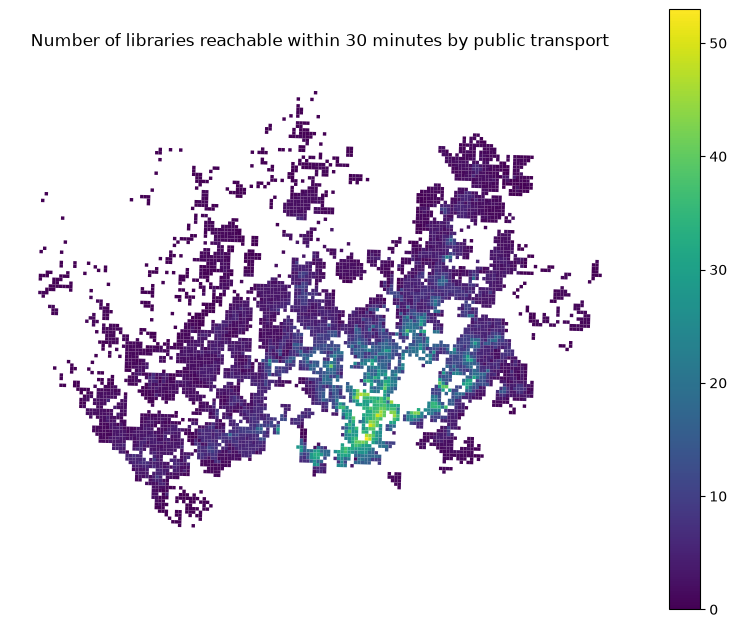

In [26]:
access_30 = pop_grid.merge(access.loc[access["budget"] == 30], left_on="id", right_on="from_id")
ax = access_30.plot(column="accessibility", cmap="viridis", legend=True, figsize=(10, 8))
ax.set_title("Number of libraries reachable within 30 minutes by public transport")
ax.set_axis_off();

Now we can see the areas with the highest access to libraries. This measure is also called **Hansen's accessibility** after its developer. `Accessibility` can also give more weight to the closer services with a **distance decay** function (the `decay` parameter), which reflects that people are less likely to visit services that are further away.

Finally, `cafein.Catchment` shows how far you can get from a location within given travel time budgets. It returns the area reached as a union of H3 hexagons for each budget:

In [27]:
reach = cafein.Catchment(network, origins=origin, departure=departure, budgets=(15, 30, 45))
gpd.GeoDataFrame(reach).sort_values("budget", ascending=False).explore(column="budget", cmap="viridis_r", style_kwds={"fillOpacity": 0.4})

## Case study: accessibility and emissions in Munich

Now that you are familiar with the basic functionalities of `cafein`, it is time to apply them to a new city: Munich, Germany. How long does it take to reach well-known places in the Munich area by public transport, by bike and by car? How much greenhouse-gas emissions does each of these trips cause? And how do the answers change from one part of the region to another? This case study shows how to answer these questions for a new area from scratch: from downloading the data, through choosing emission factors that suit the area, to comparing the travel modes.

Our **study area** is the City of Munich and the surrounding district (Landkreis München), which together cover 975 km². We calculate the travel times and emissions from 10 well-known places (our **points of interest**, POIs) to a grid of H3 hexagons that covers the whole study area.

### Get the data with transitio and pyrosm

`transitio` finds the OpenStreetMap and GTFS data for a place, downloads them and crops them to the area of interest. It relies on a **feed index**, which lists the GTFS feeds that serve each place in the world, together with the tier of service they run there (`local`, `regional`, `national` or `international`).

For Munich, the index lists several overlapping feeds: the feeds of the local operators (MVG and MVV), and Germany-wide feeds that contain the same services. We prepared the data for this case study as follows:

- **Study area**: the boundaries of the City of Munich and the Landkreis München from the `transitio` index.
- **OpenStreetMap data**: `transitio.fetch_pbf()` downloads the smallest OpenStreetMap extract covering the study area (with a 2 km margin) and crops it to the area. Under the hood, it uses `pyrosm` to compare the extracts available from different providers.
- **Public transport schedules**: the nationwide timetable data of Germany ([DELFI](https://www.delfi.de/), licensed under CC BY), which covers every local and regional service of the area (S-Bahn, U-Bahn, tram, bus and trains). We cropped it to the Munich metropolitan region and the study area, and removed the long-distance coaches and the two ferry routes on the lakes outside the study area.

Downloading and preparing the data takes about 20 minutes and needs roughly 1.5 GB of downloads, so we have prepared the files for you. **Download the Munich data package shared on the course pages and extract it into a folder called `data/munich` next to this Notebook.** The code below shows each step of the preparation; set `DOWNLOAD = True` if you want to run it yourself:

In [28]:
from pathlib import Path

data_dir = Path("data/munich")
gtfs_fp = data_dir / "munich_delfi_gtfs.zip"
osm_fp = data_dir / "munich_osm.pbf"
study_area_fp = data_dir / "munich_study_area.gpkg"

In [29]:
import shutil
import transitio

DOWNLOAD = False  # set to True to download and prepare the data yourself (takes about 20 minutes)

if DOWNLOAD:
    data_dir.mkdir(parents=True, exist_ok=True)

    # Install the transitio feed index (once, about 420 MB)
    transitio.index.refresh()

    # Study area: the City of Munich and the Landkreis München
    city = transitio.place("München", kind="city")
    district = transitio.place("Landkreis München", kind="region")
    study_area = gpd.GeoDataFrame(
        {"name": ["City + Landkreis München"]}, geometry=[city.geometry.union(district.geometry)], crs="EPSG:4326"
    )
    study_area.to_file(study_area_fp)

    # OpenStreetMap data covering the study area with a 2 km margin
    pbf = transitio.fetch_pbf(study_area.geometry.iloc[0], buffer_m=2000)
    shutil.copy(pbf, osm_fp)

    # DELFI: the nationwide public transport schedules of Germany (about 500 MB)
    db = transitio.MobilityDatabase()
    delfi = db.download_latest(db.feed("mdb-3215"))

    # Crop the schedules to the metropolitan region and the study area (+2 km)
    metro = transitio.place("München", kind="metro", definition="metropolitan region")
    margin = study_area.to_crs(epsg=25832).buffer(2000).to_crs(epsg=4326).iloc[0]
    area = gpd.GeoSeries([metro.geometry, margin], crs="EPSG:4326").union_all()
    cropped = data_dir / "delfi_cropped.zip"
    transitio.crop_feed(delfi, cropped, aoi=area)

    # Remove the long-distance coaches (route types 200-299) and the ferries (4)
    editor = transitio.FeedEditor(cropped)
    routes = editor.tables["routes.txt"]
    route_type = routes["route_type"].astype(int)
    for route_id in routes.loc[route_type.between(200, 299) | (route_type == 4), "route_id"]:
        editor.drop_route(route_id)
    editor.save(gtfs_fp, check=False)

Let's read the study area and use `pyrosm` to extract the railway lines (trains, U-Bahn and trams) from the OpenStreetMap data, so that we can draw them on our maps:

In [30]:
import pyrosm

study_area = gpd.read_file(study_area_fp)
osm = pyrosm.OSM(str(osm_fp))
rail = osm.get_data_by_custom_criteria(
    custom_filter={"railway": ["rail", "subway", "light_rail", "tram"]},
    filter_type="keep", keep_nodes=False, keep_relations=False,
)
rail["railway"].value_counts()

railway
rail      4408
subway     695
tram       683
Name: count, dtype: int64

### Points of interest and the hexagon grid

Next, let's geocode our 10 points of interest. We picked places that are spread across the study area, from the city center to the edges of the Landkreis:

In [31]:
import pandas as pd

queries = {
    "Marienplatz": "Marienplatz, München",
    "Allianz Arena": "Allianz Arena, München",
    "TUM Campus Garching": "TUM Campus Garching, Garching bei München",
    "Schloss Schleißheim": "Schloss Schleißheim, Oberschleißheim",
    "Olympiapark": "Olympiapark, München",
    "Schloss Nymphenburg": "Schloss Nymphenburg, München",
    "Klinikum Großhadern": "Klinikum Großhadern, München",
    "Tierpark Hellabrunn": "Tierpark Hellabrunn, München",
    "Bavaria Filmstadt": "Bavaria Filmstadt, Grünwald",
    "Messe München": "Messe München, München",
}
coordinates = [ox.geocode(query) for query in queries.values()]
pois = gpd.GeoDataFrame(
    {"id": list(queries)},
    geometry=[Point(lon, lat) for lat, lon in coordinates],
    crs="EPSG:4326",
)
pois["inside_study_area"] = pois.within(study_area.geometry.iloc[0])
pois

,id,geometry,inside_study_area
0,Marienplatz,POINT (11.5754 48.13714),True
1,Allianz Arena,POINT (11.62362 48.21879),True
2,TUM Campus Garching,POINT (11.67312 48.26438),True
3,Schloss Schleißheim,POINT (11.56101 48.24884),True
4,Olympiapark,POINT (11.55036 48.16871),True
5,Schloss Nymphenburg,POINT (11.50329 48.15833),True
6,Klinikum Großhadern,POINT (11.47358 48.10908),True
7,Tierpark Hellabrunn,POINT (11.5542 48.09628),True
8,Bavaria Filmstadt,POINT (11.55402 48.06543),True
9,Messe München,POINT (11.69762 48.13642),True


As we can see, all of our points of interest lie inside the study area. Our destinations are H3 hexagons at resolution 9, each covering roughly 0.1 km²:

Number of hexagons: 9890


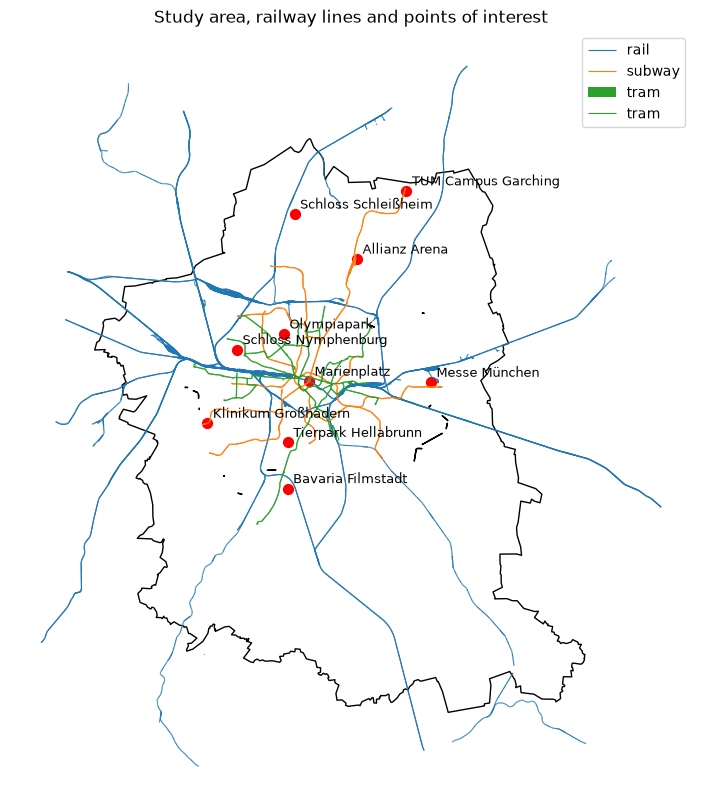

In [32]:
hexagons = zones.h3_grid(study_area, 9)
print(f"Number of hexagons: {len(hexagons)}")

ax = study_area.plot(facecolor="none", edgecolor="black", figsize=(10, 10))
rail.plot(ax=ax, column="railway", linewidth=0.8, legend=True)
pois.plot(ax=ax, color="red", markersize=50)
for _, row in pois.iterrows():
    ax.annotate(row["id"], xy=(row.geometry.x, row.geometry.y), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set_title("Study area, railway lines and points of interest")
ax.set_axis_off();

### Emission factors for Germany

The emissions of a trip depend on the emission factors of the vehicles. The default factors of `cafein` are calibrated to the Finnish electricity mix, which is cleaner than the German one, so we calculate factors that suit Munich better with `cafein.lca`. The `TransportLCA` class models the life-cycle emissions of transport modes: building the vehicles, producing their fuel or electricity, building the infrastructure, and operating the services.

The electricity mix is the main assumption we need to set. We use the German electricity generation of 2025 as published by the [Federal Statistical Office of Germany](https://www.destatis.de/DE/Presse/Pressemitteilungen/2026/03/PD26_073_43312.html) (Destatis): coal 22.1 %, natural gas 16.1 %, wind 30.0 %, photovoltaics 16.0 %, biogas 6.2 % and hydropower 3.6 %. `cafein.lca` groups the sources slightly differently, so we count wind, photovoltaics and hydropower as "other renewables", and we assign the sources that Destatis does not list separately (3.2 % of conventional and 2.8 % of renewable generation) to oil and other renewables, respectively. Nuclear power is zero, as Germany shut down its last nuclear power plants in 2023:

In [33]:
from cafein.lca import TransportLCA

germany_2025 = {
    "coal": 0.221,
    "natural_gas": 0.161,
    "oil": 0.032,
    "nuclear": 0.0,
    "biomass": 0.062,
    "other_renewables": 0.524,
}
lca = TransportLCA(power_mix=germany_2025)

`cafein.lca` covers buses and metros, but not trams or trains, so we calculate German factors for the buses and the U-Bahn and keep the default factors of `cafein` for the trams and trains. We assume that the buses run on diesel (`bus_ice`). The `identities` parameter tells `cafein` which legs each factor applies to: here, by the GTFS route type (3 for buses and 1 for the U-Bahn):

In [34]:
transit_factors = lca.transit_factors(
    modes=["bus_ice", "metro_urban_train"],
    identities={"bus_ice": {"route_type": "3"}, "metro_urban_train": {"route_type": "1"}},
)
transit_factors[["route_type", "mode", "vehicle", "fuel", "infrastructure", "operations", "basis"]].round(1)

,route_type,mode,vehicle,fuel,infrastructure,operations,basis
0,3,bus_ice,8.0,71.8,3.6,8.0,passenger_km
1,1,metro_urban_train,2.0,33.0,11.0,0.0,passenger_km


The factors are in grams of CO₂e per passenger-kilometer, split into four components: the vehicle (manufacturing), the fuel or electricity (use), the infrastructure, and the operations. `cafein` sums the components.

For cycling and driving, we calculate factors for a conventional private bike and a private petrol or diesel car (`private_car_ice`). The car factor is per vehicle-kilometer: `cafein` divides it by the number of people in the car, the **occupancy**. We use 1.46 persons, the average car occupancy in Germany in 2023 according to the [Mobilität in Deutschland](https://www.mobilitaet-in-deutschland.de/pdf/MiD2023_Ergebnisbericht.pdf) survey (weighted by distance, excluding regular work trips):

In [35]:
street_factors = lca.street_factors(
    modes=["private_bike", "private_car_ice"],
    identities={
        "private_bike": {"street_mode": "bicycle", "vehicle_class": "conventional", "service_model": "private"},
        "private_car_ice": {"street_mode": "car", "vehicle_class": "ICE", "service_model": "private"},
    },
)
occupancy = 1.46
street_factors[["street_mode", "mode", "vehicle", "fuel", "infrastructure", "operations", "basis"]].round(1)

,street_mode,mode,vehicle,fuel,infrastructure,operations,basis
0,bicycle,private_bike,7.5,0.0,9.5,0.0,passenger_km
1,car,private_car_ice,35.8,188.4,18.7,0.0,vehicle_km


### Build the networks

Now we can build the networks in the same way as for Helsinki: a `TransportNetwork` for public transport, and a `StreetNetwork` for cycling and driving. With `country="DE"`, `cafein` uses the German legal speed limits for the roads that have no speed limit tagged in OpenStreetMap:

In [36]:
%%time
network = cafein.TransportNetwork.from_gtfs(gtfs_fp, osm_pbf=osm_fp)
street_network = cafein.StreetNetwork.from_osm(osm_fp, modes=["bicycle", "car"], country="DE")
network.service_window

.../site-packages/cafein/streets.py:374: UserWarning: 7657 stop(s) are farther than 1600.0 m from the walking network and get no footpaths
  snapped = _snap_to_edges(stop_points, edges, max_snap_distance)


CPU times: user 30 s, sys: 1.38 s, total: 31.4 s
Wall time: 28.6 s


(datetime.date(2026, 9, 19), datetime.date(2026, 12, 12))

The warning tells that thousands of stops lie far from our street network. These are the stops of the metropolitan region outside our OpenStreetMap extract: the trips that pass them are still part of the network, but nobody can walk to or from them in our analysis, which is fine as all our trips start and end in the study area.

The schedules are valid for a few months only. Let's pick the next Tuesday within the service window as our travel day, and use 8 AM as the departure time:

In [37]:
start, end = network.service_window
day = max(start, datetime.date.today())
day += datetime.timedelta(days=(1 - day.weekday()) % 7)
departure = datetime.datetime.combine(day, datetime.time(8, 0))
print(f"Departure: {departure:%A %d %B %Y, %H:%M}")

Departure: Tuesday 06 October 2026, 08:00


### Travel times and emissions by public transport, bike and car

Let's calculate the travel cost matrices from our points of interest to all hexagons by each mode. We pass the German emission factors with the `factors` parameter. The street networks have no timetables, so the bike and car matrices do not need a departure time. By default, `cafein` calculates the car travel times with free-flowing traffic at the speed limits, which favors the car. To make the car trips more realistic, we add the typical delays at intersections during the morning rush hour (`intersection_delays=True` with `profile="rush"`) and five minutes for finding a parking place at the destination (`parking=True`):

In [38]:
%%time
pt = cafein.TravelCostMatrix(network, origins=pois, destinations=hexagons, departure=departure, factors=transit_factors)
bike = cafein.TravelCostMatrix(street_network, origins=pois, destinations=hexagons, transport_mode="bicycle", factors=street_factors)
car = cafein.TravelCostMatrix(
    street_network, origins=pois, destinations=hexagons, transport_mode="car", factors=street_factors, occupancy=occupancy,
    intersection_delays=True, profile="rush", parking=True,
)

costs = pd.concat([
    pd.DataFrame(pt).assign(mode="public transport"),
    pd.DataFrame(bike).assign(mode="bike"),
    pd.DataFrame(car).assign(mode="car"),
], ignore_index=True)
costs.groupby("mode")[["travel_time", "emissions"]].describe().round(0)

CPU times: user 1min 4s, sys: 243 ms, total: 1min 4s
Wall time: 7.68 s


travel_time                                             \
                       count  mean   std  min   25%   50%    75%    max   
mode                                                                      
bike                 85587.0  68.0  27.0  1.0  47.0  68.0   90.0  120.0   
car                  95960.0  49.0  14.0  6.0  39.0  49.0   58.0  104.0   
public transport     98850.0  85.0  31.0  1.0  62.0  82.0  105.0  216.0   

                 emissions                                               \
                     count    mean     std  min     25%     50%     75%   
mode                                                                      
bike               85587.0   269.0   111.0  0.0   185.0   269.0   357.0   
car                95960.0  4425.0  2179.0  0.0  2732.0  4181.0  5953.0   
public transport   98850.0   963.0   461.0  0.0   636.0   934.0  1250.0   

                           
                      max  
mode                       
bike                487.0  
car               12790.0  
public transport   3359.0

Notice that the three matrices have a different number of rows. `cafein` leaves out the destinations that are unreachable: by default, a bike or car trip may take at most 120 minutes, and some hexagons (e.g. in forests) have no streets that cars may use.

Let's summarize the median travel time and emissions from each point of interest by mode:

In [39]:
summary = costs.groupby(["from_id", "mode"])[["travel_time", "emissions"]].median().unstack("mode").round(0)
summary

travel_time                        emissions          \
mode                       bike   car public transport      bike     car   
from_id                                                                    
Allianz Arena              70.0  42.0             92.0     280.0  4484.0   
Bavaria Filmstadt          64.0  58.0             93.0     257.0  3818.0   
Klinikum Großhadern        72.0  49.0             80.0     290.0  4584.0   
Marienplatz                61.0  47.0             59.0     242.0  3463.0   
Messe München              77.0  41.0             82.0     305.0  4870.0   
Olympiapark                63.0  47.0             82.0     250.0  3894.0   
Schloss Nymphenburg        68.0  51.0             85.0     271.0  3816.0   
Schloss Schleißheim        74.0  47.0             83.0     292.0  5429.0   
TUM Campus Garching        77.0  48.0             81.0     310.0  5462.0   
Tierpark Hellabrunn        66.0  53.0             81.0     251.0  3839.0   

                                      
mode                public transport  
from_id                               
Allianz Arena                  969.0  
Bavaria Filmstadt              831.0  
Klinikum Großhadern            998.0  
Marienplatz                    645.0  
Messe München                 1016.0  
Olympiapark                    903.0  
Schloss Nymphenburg            735.0  
Schloss Schleißheim           1133.0  
TUM Campus Garching           1329.0  
Tierpark Hellabrunn            874.0

### Map the results

Let's first map the travel times by public transport from each point of interest:

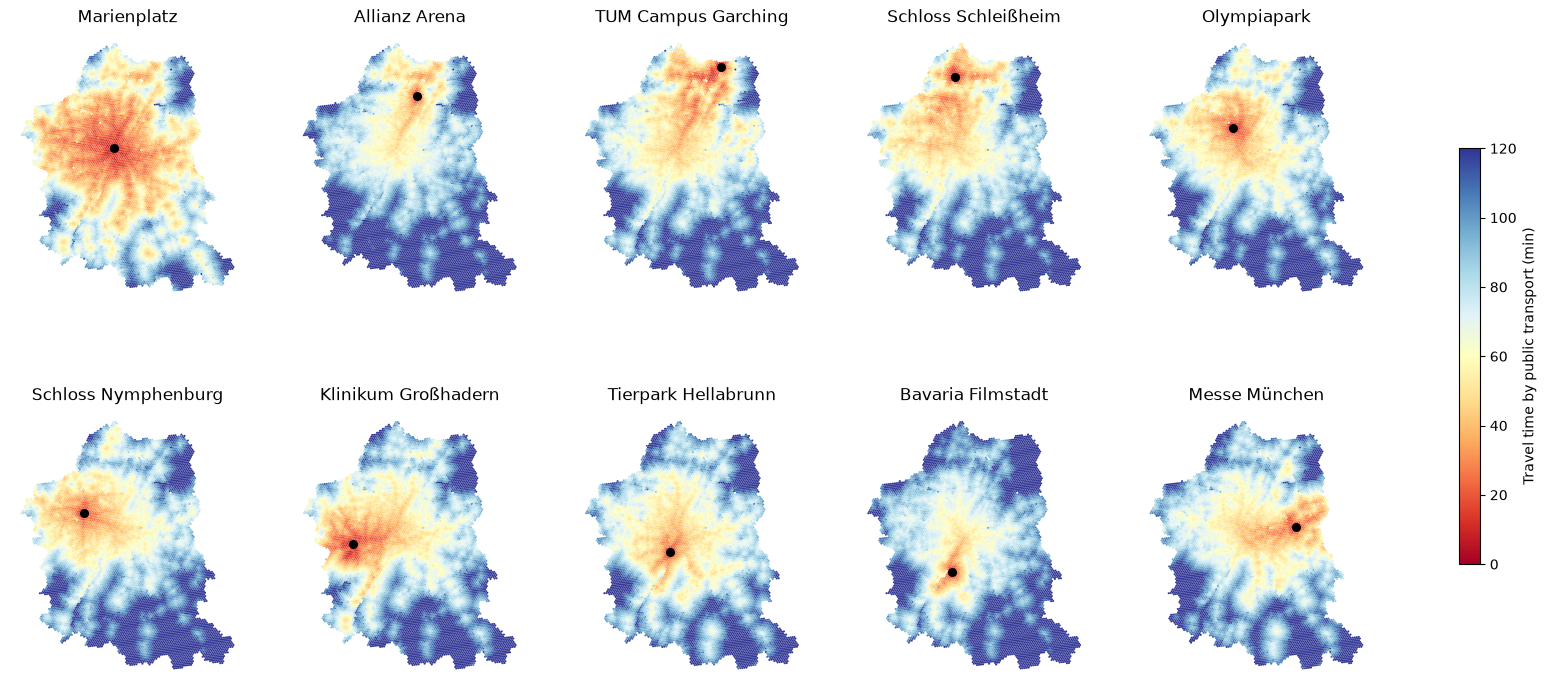

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
pt_hex = hexagons.merge(pd.DataFrame(pt), left_on="id", right_on="to_id")
for ax, (name, poi) in zip(axes.flat, pois.set_index("id").iterrows()):
    pt_hex.loc[pt_hex["from_id"] == name].plot(ax=ax, column="travel_time", cmap="RdYlBu", vmin=0, vmax=120)
    ax.scatter(poi.geometry.x, poi.geometry.y, color="black", s=30)
    ax.set_title(name)
    ax.set_axis_off()
fig.colorbar(plt.cm.ScalarMappable(cmap="RdYlBu", norm=plt.Normalize(0, 120)), ax=axes, shrink=0.6, label="Travel time by public transport (min)");

As we can see, the places in the city center, such as Marienplatz, can be reached from large parts of the study area within an hour, thanks to the S-Bahn and U-Bahn lines that meet there. The places on the edges of the region, such as the TUM Campus in Garching or Bavaria Filmstadt, are well connected along their own rail line but much harder to reach from the other side of the region. The southern parts of the Landkreis, with their large forests and sparse bus services, take a long time to reach from every point of interest.

Next, let's compare the three modes for one point of interest, Marienplatz:

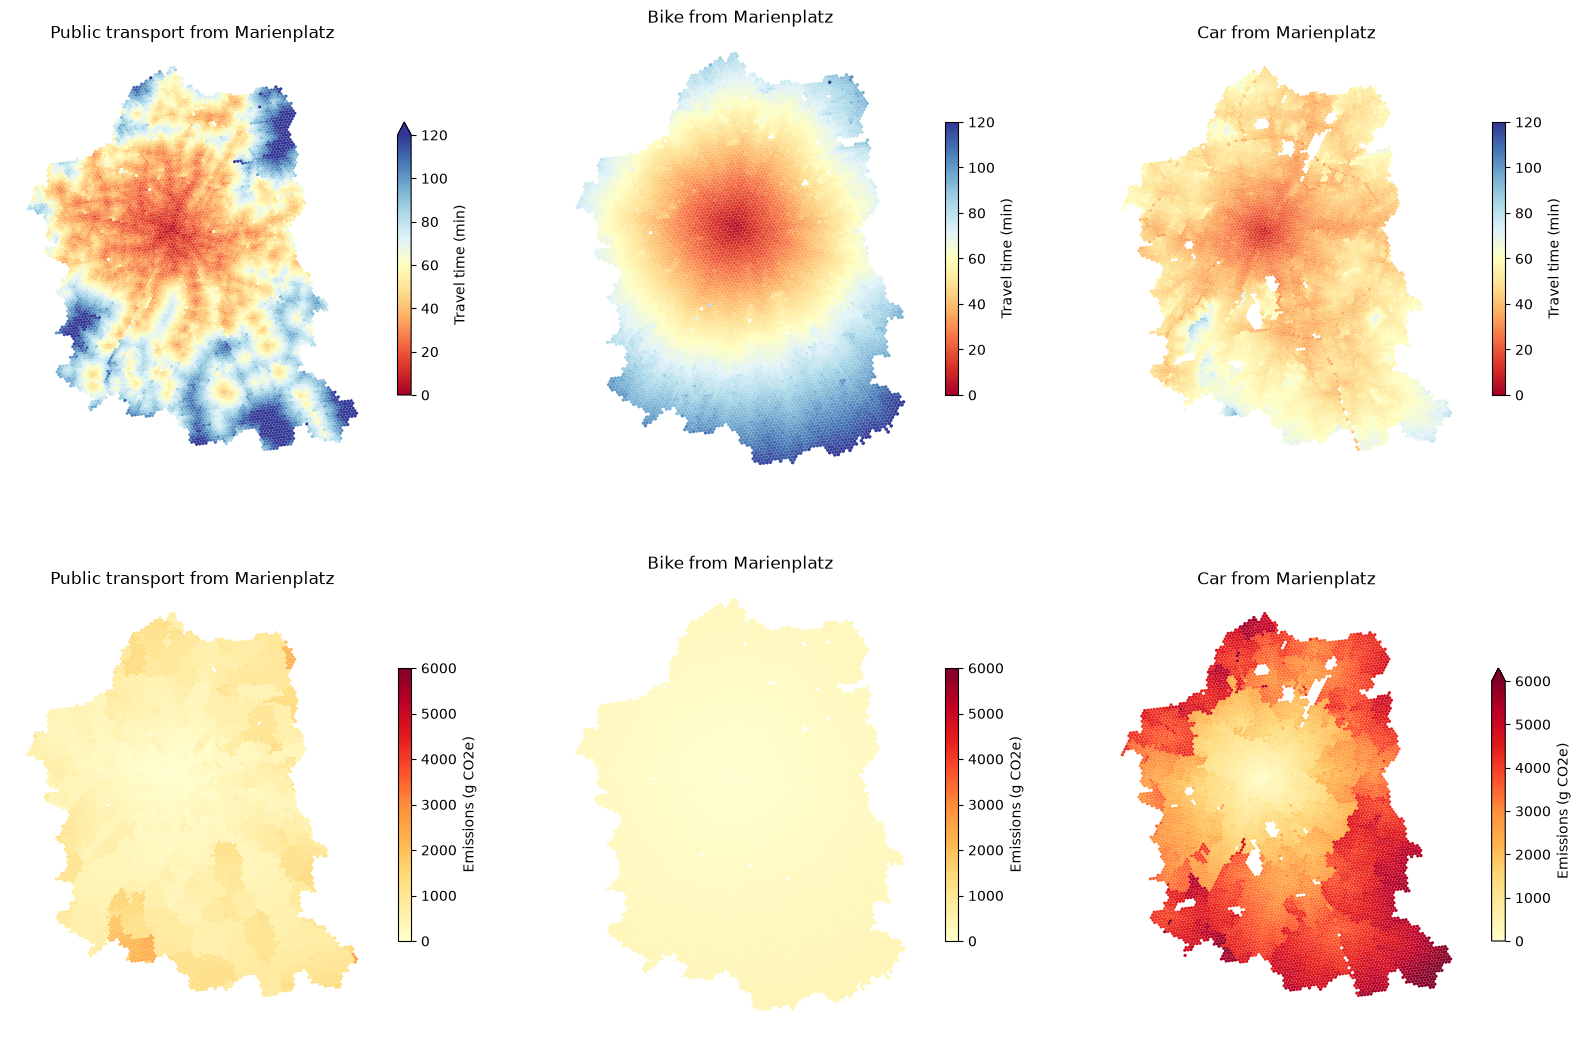

In [41]:
target = "Marienplatz"
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
for col, mode in enumerate(["public transport", "bike", "car"]):
    mode_hex = hexagons.merge(costs.loc[(costs["mode"] == mode) & (costs["from_id"] == target)], left_on="id", right_on="to_id")
    mode_hex.plot(ax=axes[0, col], column="travel_time", cmap="RdYlBu", vmin=0, vmax=120, legend=True,
                  legend_kwds={"label": "Travel time (min)", "shrink": 0.6})
    mode_hex.plot(ax=axes[1, col], column="emissions", cmap="YlOrRd", vmin=0, vmax=6000, legend=True,
                  legend_kwds={"label": "Emissions (g CO2e)", "shrink": 0.6})
    for row in range(2):
        axes[row, col].set_title(f"{mode.capitalize()} from {target}")
        axes[row, col].set_axis_off()

The maps show the trade-off between the modes: the car is the fastest mode to most hexagons, but its emissions per person are several times higher than those of public transport, and cycling causes the least emissions of the three.

### Which mode is the fastest?

Finally, let's find out the fastest mode to each hexagon from each point of interest, and how much emissions a traveler would save by taking public transport instead of the car:

In [42]:
times = costs.pivot_table(index=["from_id", "to_id"], columns="mode", values="travel_time")
fastest = times.idxmin(axis=1).rename("fastest_mode")
fastest_share = fastest.groupby(level="from_id").value_counts(normalize=True).unstack().fillna(0).round(2)
fastest_share

fastest_mode,bike,car,public transport
from_id,,,
Allianz Arena,0.05,0.94,0.01
Bavaria Filmstadt,0.41,0.59,0.01
Klinikum Großhadern,0.17,0.81,0.02
Marienplatz,0.18,0.63,0.20
Messe München,0.09,0.90,0.01
Olympiapark,0.22,0.78,0.00
Schloss Nymphenburg,0.26,0.73,0.00
Schloss Schleißheim,0.08,0.88,0.04
TUM Campus Garching,0.07,0.88,0.05


In [43]:
emissions = costs.pivot_table(index=["from_id", "to_id"], columns="mode", values="emissions")
comparison = pd.DataFrame({
    "extra_minutes_by_pt": times["public transport"] - times["car"],
    "saved_g_by_pt": emissions["car"] - emissions["public transport"],
}).dropna()
comparison.groupby(level="from_id").median().round(0)

,extra_minutes_by_pt,saved_g_by_pt
from_id,,
Allianz Arena,49.0,3406.0
Bavaria Filmstadt,36.0,2983.0
Klinikum Großhadern,31.0,3427.0
Marienplatz,10.0,2658.0
Messe München,39.0,3813.0
Olympiapark,33.0,2797.0
Schloss Nymphenburg,32.0,2992.0
Schloss Schleißheim,34.0,4216.0
TUM Campus Garching,32.0,4013.0


The first table shows that, even with the rush-hour delays and the parking search, the car is the fastest mode to most hexagons from every point of interest. The picture varies between the places, though: from Marienplatz, public transport and cycling are each the fastest mode to about a fifth of the hexagons, and from the southern places, such as Bavaria Filmstadt and Tierpark Hellabrunn, cycling wins a third or more of them. From Allianz Arena and Messe München, which lie next to the motorways on the edge of the city, the car wins about 90 % of the hexagons.

The second table shows the price of choosing public transport instead of the car: from Marienplatz, public transport takes a median of only 10 minutes longer than the car, while from the other places the difference is about half an hour or more. In return, each trip by public transport saves roughly 2.7 to 4.2 kg of CO₂e per person compared with the car.

You can continue from here in many directions, e.g. by weighting the hexagons with population data, by comparing different departure times, or by testing how electric buses (`bus_bev`) or electric cars (`private_car_bev`) would change the emissions.

## Where to go next?

In case you want to learn more, we recommend reading:

- [cafein repository](https://github.com/cafein-py/cafein), which includes more details on how to use `cafein`.
- [cafein.lca documentation](https://cafein-lca.readthedocs.io), which explains how the life-cycle emission factors are calculated.
- [transitio documentation](https://transitio.readthedocs.io), which explains how to find and download OSM and GTFS data for any area.
- Levinson, D. & H. Wu (2020). [Towards a general theory of access.](https://www.jtlu.org/index.php/jtlu/article/view/1660)